# CNN 이진분류 (컬러이미지)
- 개와고양이 데이터셋

# Basic setting

### Measuring execution time

In [26]:
!pip install --q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 5.04 s (started: 2025-01-23 03:51:16 +00:00)


### Library

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras

import requests
import zipfile
import io
import PIL
import os

time: 691 µs (started: 2025-01-23 03:51:21 +00:00)


# Data collection

### Get zip data from Url

In [28]:
# Get zip file from data_url

# 데이터 URL
data_url = 'https://raw.githubusercontent.com/20161609/data_box/main/cats_and_dogs.zip'
response = requests.get(data_url)
if response.status_code == 200:
  zip_data = io.BytesIO(response.content)  # 메모리 상에서 처리
  with zipfile.ZipFile(zip_data, 'r') as zip_ref:
    zip_ref.extractall('/content')  # 메모리 상에서 압축 해제

  data_root = '/content/cats_and_dogs'
  train_dir = data_root + '/train'
  test_dir = data_root + '/test'

  # 학습 데이터 로드
  train_cats_fnames = os.listdir(train_dir + '/cats')
  train_dogs_fnames = os.listdir(train_dir + '/dogs')
else:
    raise Exception(f"Failed to download data. Status code: {response.status_code}")


time: 2.24 s (started: 2025-01-23 03:51:21 +00:00)


In [29]:
class_name = ['cats', 'dogs']

X_train = []
y_train = []

for fname in train_cats_fnames:
    image = PIL.Image.open(train_dir + '/cats/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_train.append(arr)
    y_train.append(0)

for fname in train_dogs_fnames:
    image = PIL.Image.open(train_dir + '/dogs/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_train.append(arr)
    y_train.append(1)

len(X_train), len(y_train)

(2600, 2600)

time: 29.2 s (started: 2025-01-23 03:51:23 +00:00)


In [30]:
X_train = np.array(X_train)
y_train = np.array(y_train)

print(type(X_train), type(y_train))
print(X_train.shape, y_train.shape)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(2600, 224, 224, 3) (2600,)
time: 369 ms (started: 2025-01-23 03:51:53 +00:00)


## 2.학습, 검증 데이터 분리

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                                  shuffle=True,
                                                  random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(2080, 224, 224, 3) (520, 224, 224, 3)
(2080,) (520,)
time: 302 ms (started: 2025-01-23 03:51:53 +00:00)


In [32]:
X_train.shape

(2080, 224, 224, 3)

time: 4.25 ms (started: 2025-01-23 03:51:53 +00:00)


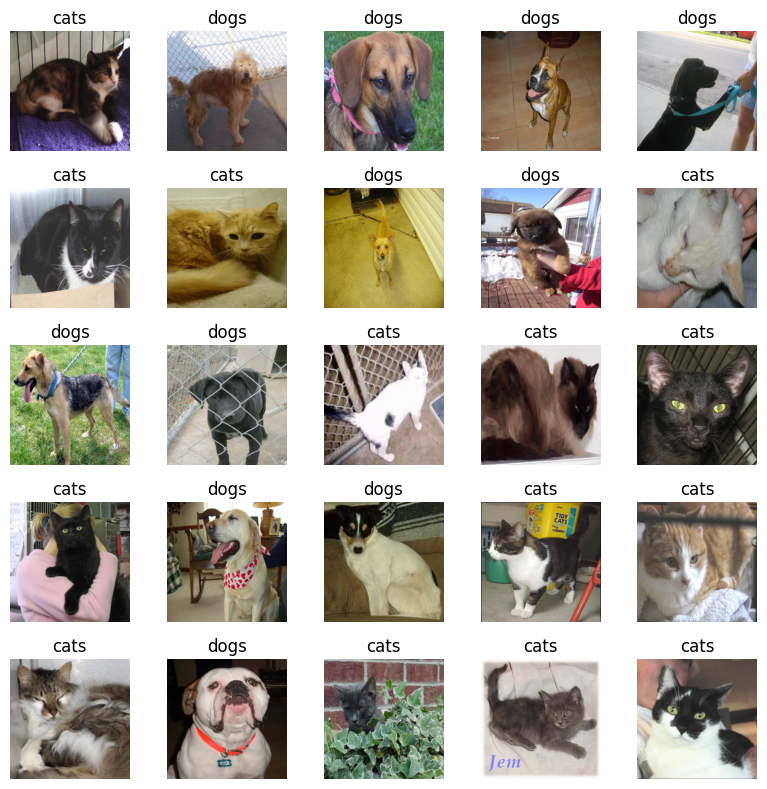

time: 2.8 s (started: 2025-01-23 03:51:53 +00:00)


In [33]:
# np.random.seed(42)
sample = np.random.randint(2080, size=25)

fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(class_name[y_train[idx]])
fig.tight_layout()
plt.show()

## 3.전처리

In [34]:
X_train_s = X_train.astype('float')/255.
X_val_s = X_val.astype('float')/255.

X_train_s.shape, X_val_s.shape

((2080, 224, 224, 3), (520, 224, 224, 3))

time: 2.68 s (started: 2025-01-23 03:51:56 +00:00)


## 4.모델

In [35]:
X_train_s.shape

(2080, 224, 224, 3)

time: 3.34 ms (started: 2025-01-23 03:51:59 +00:00)


In [36]:
from keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=3, activation='relu',
                  input_shape=(224, 224, 3)),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

time: 65 ms (started: 2025-01-23 03:51:59 +00:00)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 93312)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │      11,944,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,949,281 (45.58 MB)

 Trainable params: 11,949,281 (45.58 MB)

 Non-trainable params: 0 (0.00 B)

time: 22.1 ms (started: 2025-01-23 03:51:59 +00:00)


In [38]:
from keras import layers

model = keras.Sequential()
model.add(layers.Conv2D(filters=16, kernel_size=3, activation='relu',
                  input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


time: 129 ms (started: 2025-01-23 03:51:59 +00:00)


In [39]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 52, 52, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │      11,075,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │           4,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,103,553 (42.36 MB)

 Trainable params: 11,103,553 (42.36 MB)

 Non-trainable params: 0 (0.00 B)

time: 32.5 ms (started: 2025-01-23 03:51:59 +00:00)


In [40]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

time: 5.82 ms (started: 2025-01-23 03:51:59 +00:00)


In [46]:
from keras import callbacks

es = callbacks.EarlyStopping(monitor="val_loss",patience=5)
ckpt_path = './temp/cats_dogs.weights.h5'
ckpt = keras.callbacks.ModelCheckpoint(
    ckpt_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True
)


time: 883 µs (started: 2025-01-23 04:06:41 +00:00)


In [47]:
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    callbacks=[es, ckpt],
                    validation_data=(X_val_s, y_val))

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.5306 - loss: 0.7008 - val_accuracy: 0.6135 - val_loss: 0.6682
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6401 - loss: 0.6461 - val_accuracy: 0.6865 - val_loss: 0.6148
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7021 - loss: 0.6049 - val_accuracy: 0.6615 - val_loss: 0.6194
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7556 - loss: 0.5123 - val_accuracy: 0.6904 - val_loss: 0.5973
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7712 - loss: 0.4652 - val_accuracy: 0.7135 - val_loss: 0.6370
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8426 - loss: 0.3602 - val_accuracy: 0.7000 - val_loss: 0.6291
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8800 - loss: 0.2745 - val_accuracy: 0.7173 - val_loss: 0.7294
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9440 - loss: 0.1574 - val_accuracy: 0.7019 -

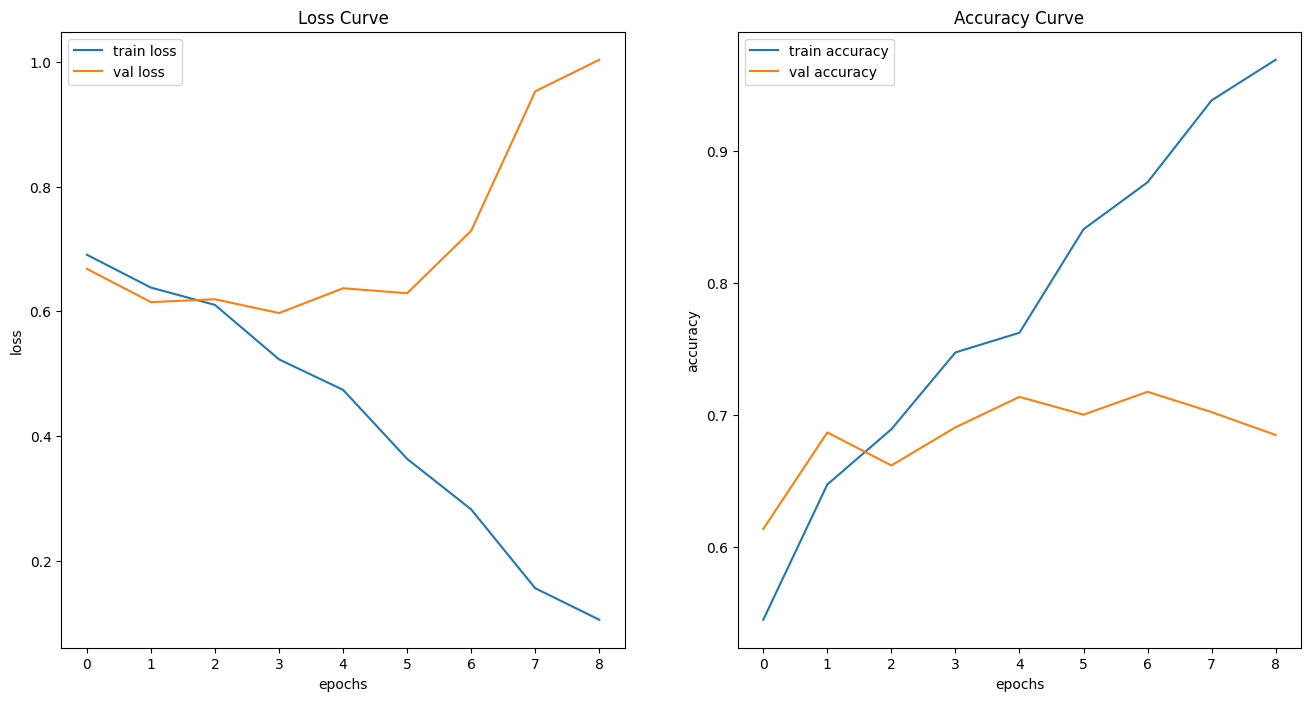

time: 311 ms (started: 2025-01-23 04:07:56 +00:00)


In [48]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

In [49]:
# 베스트 체크포인트 로딩...

model.load_weights(ckpt_path)

time: 303 ms (started: 2025-01-23 04:08:09 +00:00)


## 5.검증

In [50]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred ,average=aver))
    print('precision:', precision_score(y_true, y_pred,average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

print_metrics(y_test, y_pred, aver='macro')

NameError: name 'y_test' is not defined

time: 16.1 ms (started: 2025-01-23 04:08:13 +00:00)
